# 10 - Threshold And Hyperparameter Experiments

This notebook is for **decision-threshold** and **hyperparameter** experiments on:

- Logistic Regression
- Random Forest

Goal:
- keep the existing flight-disruption dataset and preprocessing pipeline
- run multiple training configurations
- sweep the disruption threshold
- log performance for each run
- compare **high-accuracy / low-recall** vs **higher-recall / lower-accuracy** operating points
- generate plots of all key metrics


In [34]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT


WindowsPath('C:/Code/flight-disruption-prediction')

In [35]:
import json
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

import xgboost as xgb

from src.utils import load_config
from src.model_training import ModelTrainer

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'threshold_experiments'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
config

{'opensky': {'endpoint': 'https://opensky-network.org/api/states/all',
  'polling_interval_seconds': 30,
  'collection_hours': 1,
  'clientId': '${OPENSKY_CLIENT_ID}',
  'clientSecret': '${OPENSKY_CLIENT_SECRET}',
  'bbox': {'lamin': 45.0, 'lomin': -5.0, 'lamax': 55.0, 'lomax': 10.0}},
 'trajectory': {'max_gap_minutes': 15,
  'batch_size': 200000,
  'reconstruction_workers': 4,
  'reconstruction_partitions': 16},
 'features': {'mode': 'schedule_aware_direct',
  'schedule_sources': ['bts'],
  'batch_size': 200000,
  'partitions': 16,
  'pre_departure_hours': 2,
  'post_arrival_hours': 3,
  'fallback_duration_hours': 3,
  'downsample_interval_seconds': 60,
  'phase_detail_minutes': 15,
  'phase_interval_seconds': 30,
  'max_points_per_flight': 300,
  'min_points_per_flight': 10,
  'save_trajectory_sketches': True,
  'sketch_interval_seconds': 600,
  'sketch_phase_interval_seconds': 120,
  'sketch_phase_detail_minutes': 15,
  'sketch_max_points_per_flight': 80,
  'sketch_output_file': 'tr

In [36]:
df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ml_dataset.parquet')
print(df.shape)
df.head(2)


(393339, 70)


,flight_key,region,source_dataset,scheduled_dep,scheduled_arr,origin,destination,cancelled,flight_duration,trajectory_length,mean_speed,max_speed,speed_std,mean_altitude,altitude_variance,vertical_rate_std,heading_variability,holding_pattern_count,altitude_change_count,unstable_descent_flag,trajectory_quality_score,is_full_flight,dep_anchor_confidence,arr_anchor_confidence,route_coverage_fraction,middle_gap_count,gap_fraction_of_flight,max_inter_ping_seconds,ping_interval_cv,dep_hour,dep_day_of_week,dep_month,is_weekend,is_peak_hour,origin_flight_count,dest_flight_count,origin_delay_rate,dest_delay_rate,origin_encoded,dest_encoded,route_gc_distance_km,origin_flights_1hr,dest_flights_1hr,lateral_deviation_mean_km,lateral_deviation_max_km,lateral_deviation_std_km,route_stretch_ratio,approach_deviation_km,altitude_deviation_mean_m,altitude_deviation_max_m,wind_speed,visibility,temperature,precipitation,weather_severity,weather_confidence,wind_speed_dest,visibility_dest,temperature_dest,precipitation_dest,weather_severity_dest,match_quality,label_source,match_score_minutes,match_anchor,match_confidence,training_eligible,feature_quality_score,delay_minutes,label
0,DL442_20220102,US,bts,2022-01-02 16:00:00+00:00,2022-01-02 22:47:00+00:00,KJFK,KSFO,0,2370.0,426.929740,232.273742,269.223837,47.412358,8515.887882,1.347239e+07,6.911773,125.787924,0,8,False,0.78,False,1.00,0.35,1.0,0,0.0,130.0,0.796027,16,6,1,1,1,9635,8984,0.283475,0.196594,0.024495,0.02284,4152.061082,0,6,None,None,None,None,None,None,None,11.0,3.0,53.0,0.0,1.0,High,4.0,10.0,52.0,0.0,0.0,multi_anchor_service_day<180m,bts_verified,174.666667,arrival,0.089489,True,1.0,-4.0,Normal
1,UA414_20220102,US,bts,2022-01-02 17:00:00+00:00,2022-01-02 23:14:00+00:00,KEWR,KSFO,0,1940.0,331.835305,170.392561,237.503813,49.253145,5924.061538,1.568787e+07,3.461339,186.298387,0,0,False,0.72,False,0.35,1.00,1.0,0,0.0,10.0,0.000000,17,6,1,1,1,8984,8984,0.332851,0.196482,0.022840,0.02284,4118.229321,0,8,None,None,None,None,None,None,None,12.0,10.0,56.0,0.0,0.0,High,4.0,10.0,52.0,0.0,0.0,multi_anchor_service_day<180m,bts_verified,78.500000,arrival,0.433213,True,1.0,107.0,Late


In [37]:
trainer = ModelTrainer(config)
X_train, X_test, y_train, y_test = trainer.prepare_data(df)
class_names = list(trainer.label_encoder.classes_)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
normal_idx = class_to_idx['Normal']
disrupted_indices = [idx for idx, name in enumerate(class_names) if name != 'Normal']

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Classes:', class_names)
print('Train distribution:')
print(pd.Series(trainer.label_encoder.inverse_transform(y_train)).value_counts())
print('Test distribution:')
print(pd.Series(trainer.label_encoder.inverse_transform(y_test)).value_counts())


Train shape: (359737, 39)
Test shape: (33532, 39)
Classes: ['Cancelled', 'Late', 'Normal']
Train distribution:
Normal       281959
Late          77281
Cancelled       497
Name: count, dtype: int64
Test distribution:
Normal       25697
Late          7798
Cancelled       37
Name: count, dtype: int64


## Helper Functions

Threshold logic used here:

- compute `disruption_probability = P(Late) + P(Cancelled)`
- if disruption probability is below the threshold, predict `Normal`
- if disruption probability is above the threshold, predict the most likely non-Normal class

This is useful for experimenting with an **operations-oriented** decision rule where we want to raise recall on disrupted flights.


In [38]:
def predict_with_disruption_threshold(probabilities: np.ndarray, threshold: float, normal_index: int, disrupted_index_list: list[int]) -> np.ndarray:
    probabilities = np.asarray(probabilities)
    disrupted_probability = probabilities[:, disrupted_index_list].sum(axis=1)
    preds = np.full(probabilities.shape[0], normal_index, dtype=int)

    triggered = disrupted_probability >= threshold
    if triggered.any():
        disrupted_scores = probabilities[triggered][:, disrupted_index_list]
        disrupted_choice_local = disrupted_scores.argmax(axis=1)
        preds[triggered] = np.array(disrupted_index_list)[disrupted_choice_local]
    return preds


def evaluate_threshold_run(y_true: pd.Series, y_pred: np.ndarray, probabilities: np.ndarray, threshold: float, model_name: str, params: dict, train_seconds: float) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    disrupted_true = (y_true != normal_idx).astype(int)
    disrupted_pred = (y_pred != normal_idx).astype(int)

    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    pr_auc_macro = np.nan
    if probabilities.shape[1] == y_true_bin.shape[1]:
        pr_auc_macro = average_precision_score(y_true_bin, probabilities, average='macro')

    metrics = {
        'model': model_name,
        'threshold': float(threshold),
        'train_seconds': float(train_seconds),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'disrupted_precision': float(precision_score(disrupted_true, disrupted_pred, zero_division=0)),
        'disrupted_recall': float(recall_score(disrupted_true, disrupted_pred, zero_division=0)),
        'disrupted_f1': float(f1_score(disrupted_true, disrupted_pred, zero_division=0)),
        'pr_auc_macro': None if pd.isna(pr_auc_macro) else float(pr_auc_macro),
        'mean_disruption_probability': float(probabilities[:, disrupted_indices].sum(axis=1).mean()),
        'predicted_disrupted_rate': float(disrupted_pred.mean()),
    }

    per_class_recall = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0)
    per_class_precision = precision_score(y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, labels=list(range(len(class_names))), zero_division=0)

    for idx, class_name in enumerate(class_names):
        safe_name = class_name.lower().replace(' ', '_')
        metrics[f'recall_{safe_name}'] = float(per_class_recall[idx])
        metrics[f'precision_{safe_name}'] = float(per_class_precision[idx])
        metrics[f'f1_{safe_name}'] = float(per_class_f1[idx])

    for key, value in params.items():
        metrics[f'param_{key}'] = value

    return metrics


def run_experiment_grid(model_name: str, param_grid: dict, thresholds: list[float]) -> pd.DataFrame:
    rows = []
    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]

    for combo in product(*values):
        params = dict(zip(keys, combo))
        print(f'Training {model_name}: {params}')

        if model_name == 'logistic_regression':
            model = LogisticRegression(
                random_state=trainer.seed,
                max_iter=1500,
                n_jobs=None,
                **params,
            )
        elif model_name == 'random_forest':
            model = RandomForestClassifier(
                random_state=trainer.seed,
                n_jobs=-1,
                **params,
            )
        elif model_name == 'xgboost':
            model = xgb.XGBClassifier(
                objective='multi:softprob',
                num_class=len(class_names),
                random_state=trainer.seed,
                tree_method='hist',
                eval_metric='mlogloss',
                **params,
            )
        else:
            raise ValueError(f'Unsupported model: {model_name}')

        start = time.perf_counter()
        model.fit(X_train, y_train)
        train_seconds = time.perf_counter() - start
        probabilities = model.predict_proba(X_test)

        for threshold in thresholds:
            y_pred = predict_with_disruption_threshold(probabilities, threshold, normal_idx, disrupted_indices)
            rows.append(
                evaluate_threshold_run(
                    y_true=y_test,
                    y_pred=y_pred,
                    probabilities=probabilities,
                    threshold=threshold,
                    model_name=model_name,
                    params=params,
                    train_seconds=train_seconds,
                )
            )

    return pd.DataFrame(rows)

## Experiment Space

The grids are intentionally moderate so the notebook stays practical.

You can widen them later if you want deeper sweeps.


In [39]:
thresholds = [round(x, 2) for x in np.arange(0.20, 0.81, 0.05)]

logistic_grid = {
    'C': [0.25, 1.0, 4.0],
    'class_weight': [None, 'balanced'],
}

random_forest_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 12],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced', 'balanced_subsample'],
}

xgb_params_path = PROJECT_ROOT / 'models' / 'best_params_xgboost.json'
if xgb_params_path.exists():
    xgb_best_params = json.loads(xgb_params_path.read_text(encoding='utf-8'))
else:
    xgb_best_params = {
        'max_depth': 6,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 2,
    }

xgboost_grid = {
    'max_depth': sorted(set([int(xgb_best_params.get('max_depth', 6)), 4, 8])),
    'learning_rate': sorted(set([float(xgb_best_params.get('learning_rate', 0.05)), 0.03, 0.10])),
    'n_estimators': sorted(set([int(xgb_best_params.get('n_estimators', 300)), 200, 400])),
    'subsample': [float(xgb_best_params.get('subsample', 0.8))],
    'colsample_bytree': [float(xgb_best_params.get('colsample_bytree', 0.8))],
    'min_child_weight': [int(xgb_best_params.get('min_child_weight', 2))],
}

thresholds, logistic_grid, random_forest_grid, xgboost_grid

([np.float64(0.2),
  np.float64(0.25),
  np.float64(0.3),
  np.float64(0.35),
  np.float64(0.4),
  np.float64(0.45),
  np.float64(0.5),
  np.float64(0.55),
  np.float64(0.6),
  np.float64(0.65),
  np.float64(0.7),
  np.float64(0.75),
  np.float64(0.8)],
 {'C': [0.25, 1.0, 4.0], 'class_weight': [None, 'balanced']},
 {'n_estimators': [200, 400],
  'max_depth': [None, 12],
  'min_samples_leaf': [1, 5],
  'class_weight': ['balanced', 'balanced_subsample']},
 {'max_depth': [4, 8, 10],
  'learning_rate': [0.03, 0.07565348500076723, 0.1],
  'n_estimators': [200, 323, 400],
  'subsample': [0.6726016665799541],
  'colsample_bytree': [0.8045777034794684],
  'min_child_weight': [5]})

## Run Logistic Regression Experiments

In [40]:
lr_results = run_experiment_grid('logistic_regression', logistic_grid, thresholds)
lr_results.head()


Training logistic_regression: {'C': 0.25, 'class_weight': None}
Training logistic_regression: {'C': 0.25, 'class_weight': 'balanced'}
Training logistic_regression: {'C': 1.0, 'class_weight': None}
Training logistic_regression: {'C': 1.0, 'class_weight': 'balanced'}
Training logistic_regression: {'C': 4.0, 'class_weight': None}
Training logistic_regression: {'C': 4.0, 'class_weight': 'balanced'}


,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_cancelled,precision_cancelled,f1_cancelled,recall_late,precision_late,f1_late,recall_normal,precision_normal,f1_normal,param_C,param_class_weight
0,logistic_regression,0.20,9.702671,0.617261,0.646508,0.386301,0.426381,0.341052,0.680536,0.454387,0.435415,0.218199,0.466241,0.0,0.0,0.0,0.680046,0.339197,0.452629,0.599097,0.860152,0.706274,0.25,NaN
1,logistic_regression,0.25,9.702671,0.704372,0.716156,0.415555,0.426041,0.398599,0.515763,0.449675,0.435415,0.218199,0.302338,0.0,0.0,0.0,0.515389,0.396429,0.448149,0.762735,0.837822,0.798517,0.25,NaN
2,logistic_regression,0.30,9.702671,0.746183,0.737392,0.415073,0.411089,0.449516,0.373325,0.407893,0.435415,0.218199,0.194053,0.0,0.0,0.0,0.372660,0.446596,0.406292,0.860606,0.818316,0.838929,0.25,NaN
3,logistic_regression,0.35,9.702671,0.765895,0.736097,0.398573,0.392539,0.499876,0.256414,0.338957,0.435415,0.218199,0.119856,0.0,0.0,0.0,0.255835,0.496392,0.337649,0.921781,0.802595,0.858069,0.25,NaN
4,logistic_regression,0.40,9.702671,0.772695,0.724764,0.376388,0.376530,0.544913,0.174984,0.264902,0.435415,0.218199,0.075033,0.0,0.0,0.0,0.174147,0.539746,0.263331,0.955442,0.791591,0.865833,0.25,NaN


## Run Random Forest Experiments

In [41]:
rf_results = run_experiment_grid('random_forest', random_forest_grid, thresholds)
rf_results.head()


Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'class_weight': 'balanced'}
Training random_forest: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}
Training random_forest: {'n_estimators':

,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_cancelled,precision_cancelled,f1_cancelled,recall_late,precision_late,f1_late,recall_normal,precision_normal,f1_normal,param_n_estimators,param_max_depth,param_min_samples_leaf,param_class_weight
0,random_forest,0.20,85.587895,0.700913,0.723501,0.445380,0.497007,0.428562,0.827696,0.564723,0.577123,0.220276,0.451270,0.0,0.0,0.0,0.827520,0.426447,0.562843,0.663502,0.926630,0.773295,200,NaN,1,balanced
1,random_forest,0.25,85.587895,0.770637,0.782624,0.478798,0.503903,0.507624,0.726611,0.597690,0.577123,0.220276,0.334457,0.0,0.0,0.0,0.726597,0.505216,0.596013,0.785111,0.904019,0.840380,200,NaN,1,balanced
2,random_forest,0.30,85.587895,0.809704,0.810806,0.492353,0.495349,0.590276,0.616720,0.603208,0.577123,0.220276,0.244125,0.0,0.0,0.0,0.616568,0.587344,0.601602,0.869479,0.881520,0.875458,200,NaN,1,balanced
3,random_forest,0.35,85.587895,0.827926,0.819209,0.491736,0.480021,0.673653,0.516911,0.584964,0.577123,0.220276,0.179291,0.0,0.0,0.0,0.516414,0.669827,0.583201,0.923649,0.862464,0.892008,200,NaN,1,balanced
4,random_forest,0.40,85.587895,0.829029,0.809907,0.475545,0.456801,0.741884,0.414167,0.531575,0.577123,0.220276,0.130443,0.0,0.0,0.0,0.414337,0.738683,0.530891,0.956065,0.842582,0.895743,200,NaN,1,balanced


## Run XGBoost Experiments

In [42]:
xgb_results = run_experiment_grid('xgboost', xgboost_grid, thresholds)
xgb_results.head()


Training xgboost: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 0.6726016665799541, 'colsample_bytree': 0.8045777034794684, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 323, 'subsample': 0.6726016665799541, 'colsample_bytree': 0.8045777034794684, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 400, 'subsample': 0.6726016665799541, 'colsample_bytree': 0.8045777034794684, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.07565348500076723, 'n_estimators': 200, 'subsample': 0.6726016665799541, 'colsample_bytree': 0.8045777034794684, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.07565348500076723, 'n_estimators': 323, 'subsample': 0.6726016665799541, 'colsample_bytree': 0.8045777034794684, 'min_child_weight': 5}
Training xgboost: {'max_depth': 4, 'learning_rate': 0.07565348500076723, 'n_estimators': 400, '

,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_cancelled,precision_cancelled,f1_cancelled,recall_late,precision_late,f1_late,recall_normal,precision_normal,f1_normal,param_max_depth,param_learning_rate,param_n_estimators,param_subsample,param_colsample_bytree,param_min_child_weight
0,xgboost,0.20,21.929117,0.677681,0.702113,0.460458,0.492627,0.402479,0.775112,0.529838,0.530964,0.222187,0.449988,0.054054,0.5,0.097561,0.774686,0.400464,0.527990,0.649142,0.904462,0.755822,4,0.03,200,0.672602,0.804578,5
1,xgboost,0.25,21.929117,0.747048,0.759252,0.489169,0.493710,0.471165,0.649649,0.546196,0.530964,0.222187,0.322170,0.054054,0.5,0.097561,0.649397,0.468932,0.544604,0.777678,0.879229,0.825342,4,0.03,200,0.672602,0.804578,5
2,xgboost,0.30,21.929117,0.784773,0.783223,0.496458,0.480762,0.542245,0.523421,0.532667,0.530964,0.222187,0.225546,0.054054,0.5,0.097561,0.522955,0.539489,0.531093,0.865276,0.856213,0.860721,4,0.03,200,0.672602,0.804578,5
3,xgboost,0.35,21.929117,0.799744,0.783676,0.485225,0.458601,0.611100,0.400511,0.483886,0.530964,0.222187,0.153137,0.054054,0.5,0.097561,0.399461,0.607094,0.481862,0.922287,0.834595,0.876252,4,0.03,200,0.672602,0.804578,5
4,xgboost,0.40,21.929117,0.803978,0.774303,0.467165,0.438827,0.680893,0.307466,0.423635,0.530964,0.222187,0.105511,0.054054,0.5,0.097561,0.306361,0.676005,0.421638,0.956065,0.819097,0.882297,4,0.03,200,0.672602,0.804578,5


## Combine And Save Results

In [43]:
results = pd.concat([lr_results, rf_results, xgb_results], ignore_index=True)
results = results.sort_values(['model', 'threshold', 'macro_f1'], ascending=[True, True, False]).reset_index(drop=True)

csv_path = OUTPUT_DIR / 'threshold_hyperparameter_experiments.csv'
parquet_path = OUTPUT_DIR / 'threshold_hyperparameter_experiments.parquet'
results.to_csv(csv_path, index=False)
results.to_parquet(parquet_path, index=False)

print('Saved CSV:', csv_path)
print('Saved Parquet:', parquet_path)
print('Rows logged:', len(results))
results.head()

Saved CSV: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\threshold_hyperparameter_experiments.csv
Saved Parquet: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\threshold_hyperparameter_experiments.parquet
Rows logged: 637


,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_cancelled,precision_cancelled,f1_cancelled,recall_late,precision_late,f1_late,recall_normal,precision_normal,f1_normal,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight
0,logistic_regression,0.2,10.179491,0.617530,0.646752,0.386426,0.426438,0.341207,0.680281,0.454468,0.437427,0.218084,0.465854,0.00000,0.000000,0.000000,0.679790,0.339351,0.452709,0.599525,0.860142,0.706568,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,logistic_regression,0.2,9.702671,0.617261,0.646508,0.386301,0.426381,0.341052,0.680536,0.454387,0.435415,0.218199,0.466241,0.00000,0.000000,0.000000,0.680046,0.339197,0.452629,0.599097,0.860152,0.706274,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,logistic_regression,0.2,10.116190,0.617052,0.646318,0.386198,0.426320,0.340919,0.680664,0.454298,0.437153,0.218201,0.466510,0.00000,0.000000,0.000000,0.680174,0.339065,0.452540,0.598786,0.860138,0.706052,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logistic_regression,0.2,3.365492,0.232107,0.100125,0.138387,0.415924,0.234322,0.995278,0.379336,0.426975,0.516609,0.992455,0.27027,0.011976,0.022936,0.969095,0.232924,0.375578,0.008406,0.853755,0.016647,0.25,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,logistic_regression,0.2,3.237850,0.232107,0.100125,0.138387,0.415924,0.234322,0.995278,0.379336,0.426986,0.516595,0.992455,0.27027,0.011976,0.022936,0.969095,0.232924,0.375578,0.008406,0.853755,0.016647,1.00,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Best Configurations By Different Objectives

This helps compare two different product goals:

- **best accuracy**
- **best disrupted recall**


In [44]:
summary_views = {
    'best_accuracy': results.sort_values(['accuracy', 'macro_f1', 'disrupted_recall'], ascending=False).groupby('model').head(5),
    'best_disrupted_recall': results.sort_values(['disrupted_recall', 'macro_f1', 'accuracy'], ascending=False).groupby('model').head(5),
    'best_macro_f1': results.sort_values(['macro_f1', 'disrupted_recall', 'accuracy'], ascending=False).groupby('model').head(5),
}

for name, frame in summary_views.items():
    print(f'\n{name.upper()}')
    display_cols = [
        'model', 'threshold', 'accuracy', 'weighted_f1', 'macro_f1', 'macro_recall',
        'disrupted_precision', 'disrupted_recall', 'disrupted_f1', 'train_seconds',
        'param_C', 'param_class_weight', 'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf'
    ]
    display(frame[[c for c in display_cols if c in frame.columns]].reset_index(drop=True))



BEST_ACCURACY


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,xgboost,0.45,0.847966,0.837955,0.508389,0.492103,0.747753,0.530823,0.620885,54.035679,NaN,NaN,400.0,10.0,NaN
1,xgboost,0.50,0.847728,0.833859,0.501738,0.481756,0.781397,0.486790,0.599874,54.035679,NaN,NaN,400.0,10.0,NaN
2,xgboost,0.45,0.847399,0.837082,0.507340,0.490814,0.748322,0.526356,0.618013,44.347525,NaN,NaN,323.0,10.0,NaN
3,xgboost,0.50,0.847370,0.833031,0.500625,0.480350,0.784363,0.481429,0.596647,44.347525,NaN,NaN,323.0,10.0,NaN
4,xgboost,0.50,0.847250,0.834134,0.518692,0.492123,0.772873,0.493810,0.602601,53.282640,NaN,NaN,400.0,10.0,NaN
5,random_forest,0.40,0.830103,0.810466,0.475722,0.456553,0.750816,0.411104,0.531299,175.378729,NaN,balanced_subsample,400.0,NaN,1.0
6,random_forest,0.40,0.829596,0.809741,0.474890,0.455767,0.750059,0.408679,0.529081,151.574091,NaN,balanced,400.0,NaN,1.0
7,random_forest,0.40,0.829029,0.809907,0.475545,0.456801,0.741884,0.414167,0.531575,85.587895,NaN,balanced,200.0,NaN,1.0
8,random_forest,0.35,0.828880,0.819483,0.491464,0.478947,0.680272,0.510530,0.583303,151.574091,NaN,balanced,400.0,NaN,1.0
9,random_forest,0.40,0.828045,0.808855,0.474465,0.455926,0.738128,0.412636,0.529349,86.736156,NaN,balanced_subsample,200.0,NaN,1.0



BEST_DISRUPTED_RECALL


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.20,0.238966,0.102209,0.169726,0.416223,0.235284,0.999872,0.380929,50.103592,NaN,balanced_subsample,200.0,12.0,5.0
1,random_forest,0.20,0.238459,0.101435,0.168597,0.433816,0.235192,0.999872,0.380809,48.629699,NaN,balanced,200.0,12.0,5.0
2,random_forest,0.20,0.237564,0.099677,0.164400,0.415435,0.234994,0.999872,0.380550,92.971563,NaN,balanced,400.0,12.0,1.0
3,random_forest,0.20,0.237296,0.099006,0.161462,0.415407,0.234910,0.999872,0.380439,47.024505,NaN,balanced,200.0,12.0,1.0
4,random_forest,0.20,0.240367,0.105165,0.169986,0.416773,0.235607,0.999745,0.381344,139.810951,NaN,balanced_subsample,400.0,12.0,5.0
5,logistic_regression,0.20,0.232107,0.100125,0.138387,0.415924,0.234322,0.995278,0.379336,3.365492,0.25,balanced,NaN,NaN,NaN
6,logistic_regression,0.20,0.232107,0.100125,0.138387,0.415924,0.234322,0.995278,0.379336,3.237850,1.00,balanced,NaN,NaN,NaN
7,logistic_regression,0.20,0.232107,0.100125,0.138387,0.415924,0.234322,0.995278,0.379336,3.187870,4.00,balanced,NaN,NaN,NaN
8,logistic_regression,0.25,0.248419,0.135385,0.154511,0.421322,0.237323,0.988003,0.382716,3.237850,1.00,balanced,NaN,NaN,NaN
9,logistic_regression,0.25,0.248419,0.135385,0.154511,0.421322,0.237323,0.988003,0.382716,3.187870,4.00,balanced,NaN,NaN,NaN



BEST_MACRO_F1


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.45,0.816742,0.814602,0.537064,0.516824,0.616125,0.580345,0.597700,152.013022,NaN,balanced_subsample,400.0,NaN,5.0
1,random_forest,0.45,0.814595,0.812807,0.536695,0.516068,0.610047,0.581238,0.595294,81.175223,NaN,balanced_subsample,200.0,NaN,5.0
2,xgboost,0.35,0.828820,0.826719,0.535803,0.519006,0.643739,0.605616,0.624096,22.609545,NaN,NaN,200.0,8.0,NaN
3,xgboost,0.40,0.837379,0.829987,0.534463,0.509092,0.694940,0.546905,0.612099,22.609545,NaN,NaN,200.0,8.0,NaN
4,xgboost,0.30,0.814923,0.818332,0.532535,0.527521,0.593761,0.668028,0.628709,22.609545,NaN,NaN,200.0,8.0,NaN
5,xgboost,0.35,0.826703,0.822268,0.532130,0.509391,0.649059,0.567709,0.605664,31.703546,NaN,NaN,200.0,10.0,NaN
6,random_forest,0.40,0.791453,0.798590,0.531470,0.528363,0.544680,0.677601,0.603913,152.013022,NaN,balanced_subsample,400.0,NaN,5.0
7,random_forest,0.40,0.789634,0.796918,0.531116,0.527125,0.541326,0.675431,0.600988,81.175223,NaN,balanced_subsample,200.0,NaN,5.0
8,xgboost,0.30,0.811613,0.813882,0.530422,0.519501,0.590732,0.639438,0.614121,31.703546,NaN,NaN,200.0,10.0,NaN
9,random_forest,0.50,0.824526,0.813471,0.529808,0.497878,0.675512,0.484110,0.564015,81.175223,NaN,balanced_subsample,200.0,NaN,5.0


## Prepare Plot Frames

In [45]:
metric_cols = [
    'accuracy', 'weighted_f1', 'macro_f1', 'macro_recall',
    'disrupted_precision', 'disrupted_recall', 'disrupted_f1', 'pr_auc_macro',
]

best_by_macro_f1 = (
    results.sort_values(['model', 'macro_f1', 'disrupted_recall', 'accuracy'], ascending=[True, False, False, False])
    .groupby('model')
    .head(1)
)

plot_frames = []
for _, best_row in best_by_macro_f1.iterrows():
    model_name = best_row['model']
    model_subset = results[results['model'] == model_name].copy()

    param_cols = [col for col in model_subset.columns if col.startswith('param_')]
    for param_col in param_cols:
        if param_col in best_row.index and pd.notna(best_row[param_col]):
            model_subset = model_subset[model_subset[param_col] == best_row[param_col]]

    plot_frames.append(model_subset)

plot_df = pd.concat(plot_frames, ignore_index=True)
plot_df.head()

,model,threshold,train_seconds,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,pr_auc_macro,mean_disruption_probability,predicted_disrupted_rate,recall_cancelled,precision_cancelled,f1_cancelled,recall_late,precision_late,f1_late,recall_normal,precision_normal,f1_normal,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight
0,logistic_regression,0.20,3.23785,0.232107,0.100125,0.138387,0.415924,0.234322,0.995278,0.379336,0.426986,0.516595,0.992455,0.27027,0.011976,0.022936,0.969095,0.232924,0.375578,0.008406,0.853755,0.016647,1.0,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,logistic_regression,0.25,3.23785,0.248419,0.135385,0.154511,0.421322,0.237323,0.988003,0.382716,0.426986,0.516595,0.972742,0.27027,0.011976,0.022936,0.961785,0.235975,0.378970,0.031910,0.897155,0.061629,1.0,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,logistic_regression,0.30,3.23785,0.285667,0.210062,0.188885,0.433534,0.244517,0.970517,0.390620,0.426986,0.516595,0.927413,0.27027,0.012005,0.022989,0.944601,0.243383,0.387043,0.085730,0.905094,0.156624,1.0,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logistic_regression,0.35,3.23785,0.346952,0.319062,0.239328,0.452003,0.257169,0.935163,0.403403,0.426986,0.516595,0.849666,0.27027,0.012063,0.023095,0.909336,0.256344,0.399944,0.176402,0.899226,0.294944,1.0,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,logistic_regression,0.40,3.23785,0.423655,0.434382,0.293409,0.473129,0.275484,0.882323,0.419873,0.426986,0.516595,0.748360,0.27027,0.012151,0.023256,0.856630,0.275226,0.416602,0.292486,0.890732,0.440369,1.0,balanced,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot 1: All Key Metrics vs Threshold

For each model, this uses the **best macro-F1 hyperparameter setting**, then plots all major metrics across thresholds.


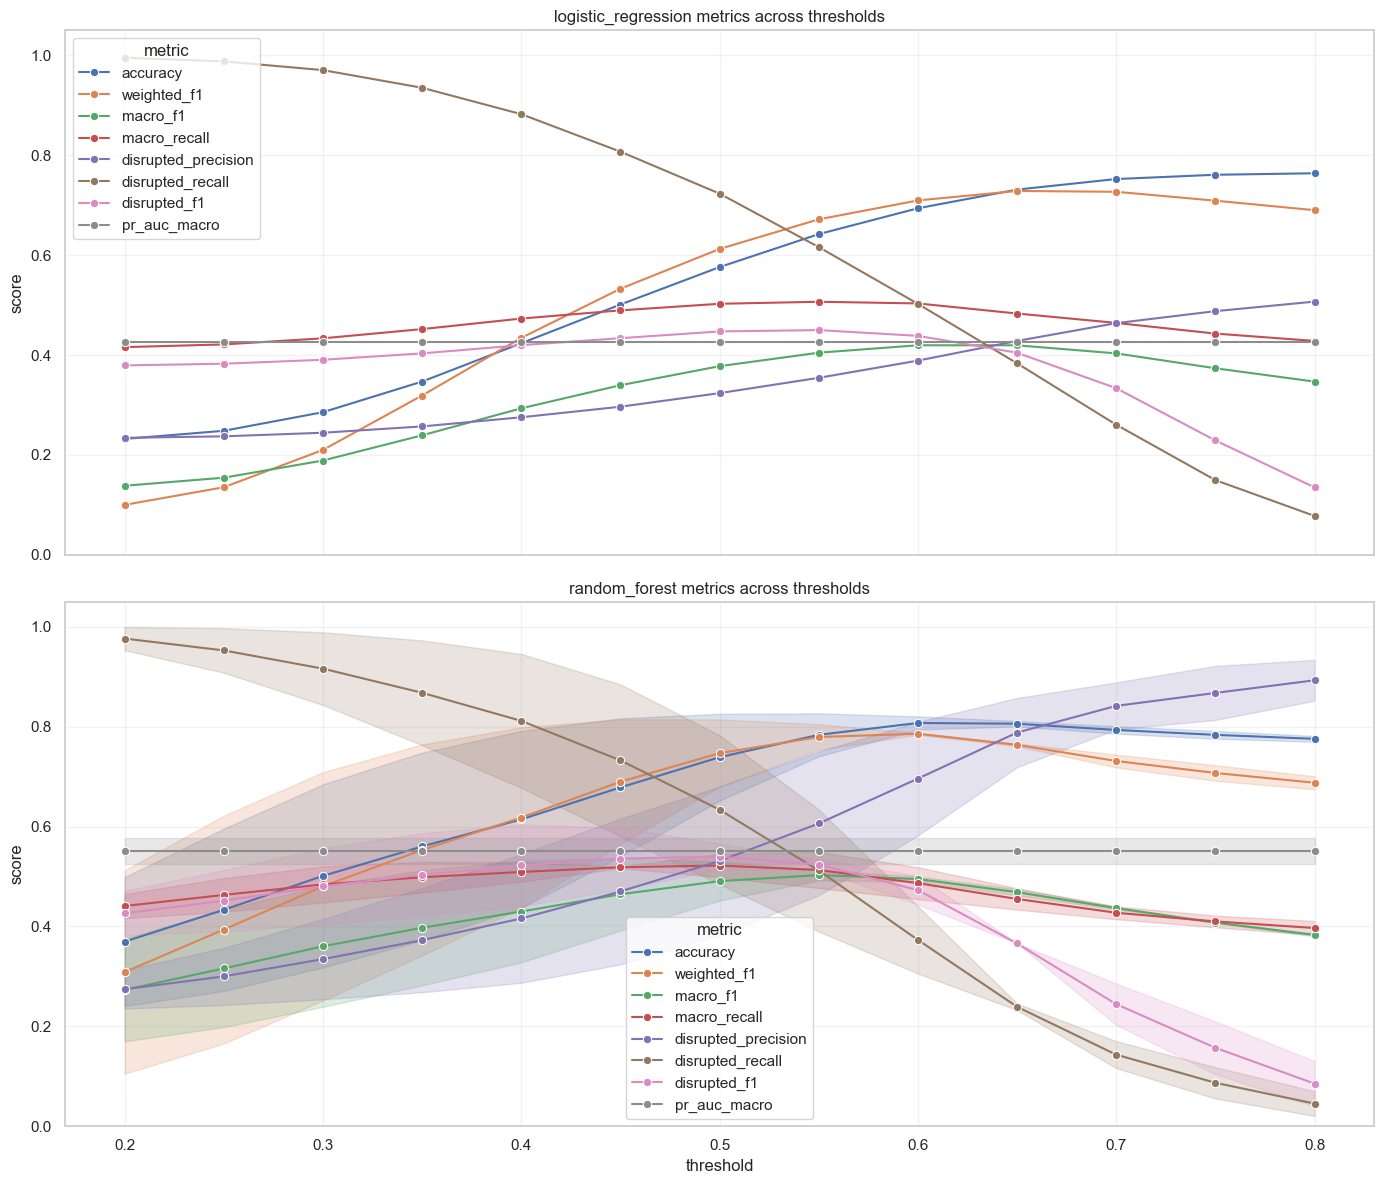

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\metrics_vs_threshold.png


In [46]:
long_df = plot_df.melt(
    id_vars=['model', 'threshold'],
    value_vars=metric_cols,
    var_name='metric',
    value_name='score',
)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
for ax, model_name in zip(axes, sorted(long_df['model'].unique())):
    subset = long_df[long_df['model'] == model_name]
    sns.lineplot(data=subset, x='threshold', y='score', hue='metric', marker='o', ax=ax)
    ax.set_title(f'{model_name} metrics across thresholds')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plot1_path = OUTPUT_DIR / 'metrics_vs_threshold.png'
plt.savefig(plot1_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot1_path)


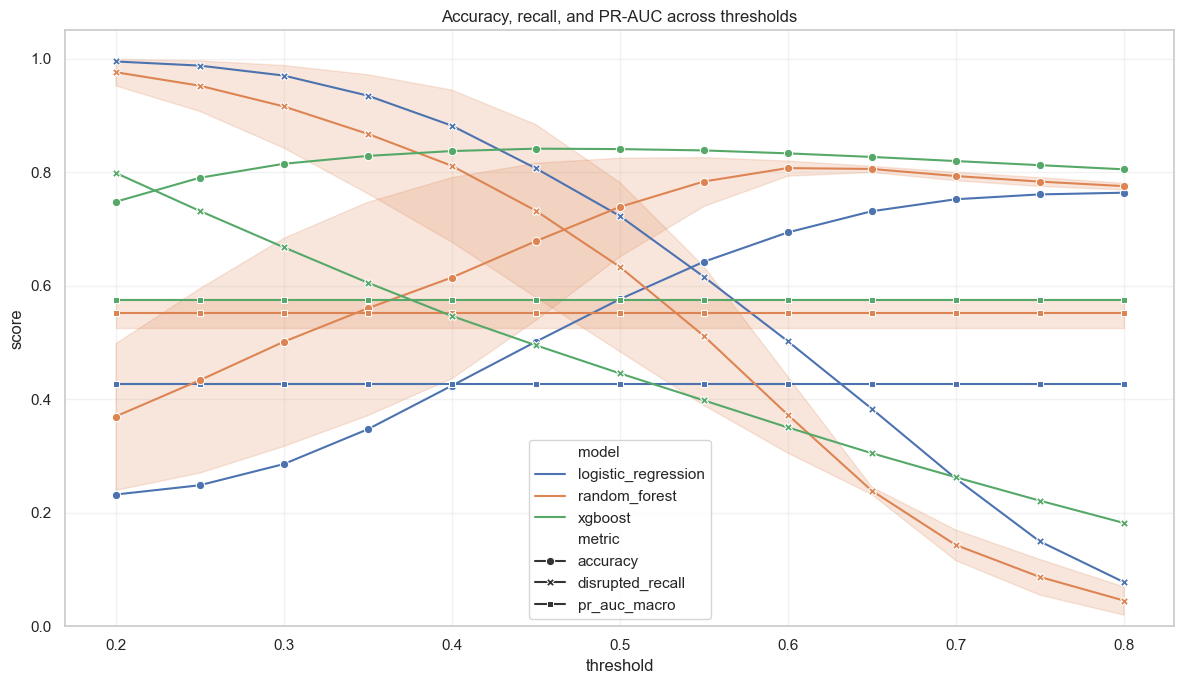

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\accuracy_recall_prauc_combined.png


In [47]:
metrics_for_plot = ['accuracy', 'disrupted_recall']
if 'pr_auc_macro' in plot_df.columns:
    metrics_for_plot.append('pr_auc_macro')

long_simple = plot_df[['model', 'threshold', *metrics_for_plot]].melt(
    id_vars=['model', 'threshold'],
    value_vars=metrics_for_plot,
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=long_simple,
    x='threshold',
    y='score',
    hue='model',
    style='metric',
    markers=True,
    dashes=False,
)

plt.title('Accuracy, recall, and PR-AUC across thresholds')
plt.ylabel('score')
plt.xlabel('threshold')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.25)
plt.tight_layout()

single_plot_path = OUTPUT_DIR / 'accuracy_recall_prauc_combined.png'
plt.savefig(single_plot_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', single_plot_path)

## Plot 2: Accuracy vs Disrupted Recall

This shows the operating-point tradeoff directly.


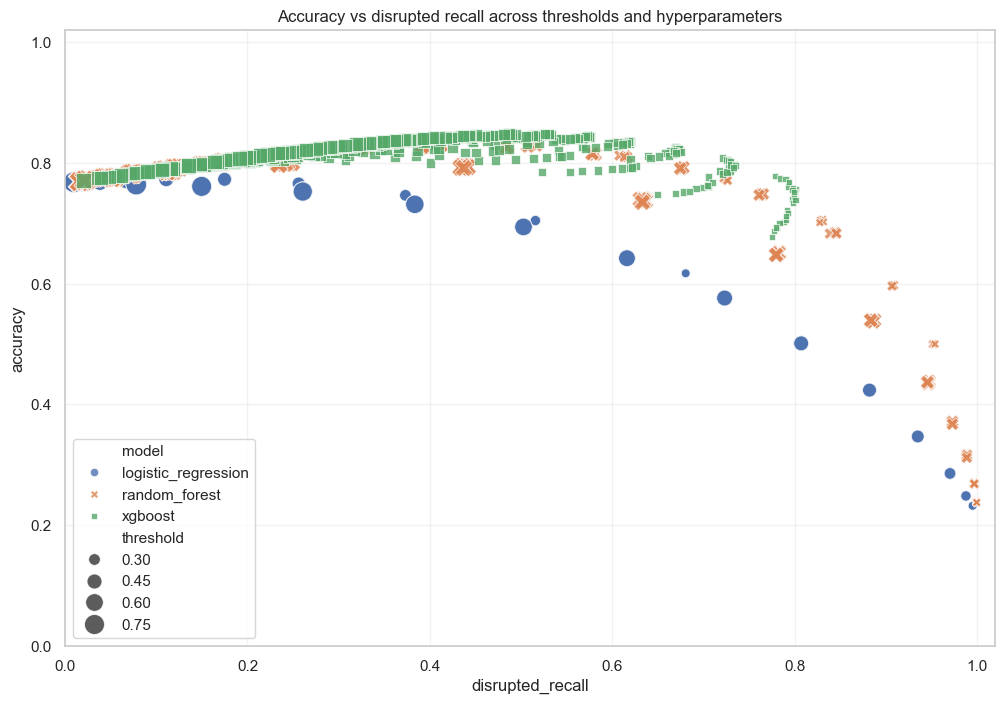

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\accuracy_vs_disrupted_recall.png


In [48]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=results,
    x='disrupted_recall',
    y='accuracy',
    hue='model',
    style='model',
    size='threshold',
    sizes=(40, 220),
    alpha=0.8,
)
plt.title('Accuracy vs disrupted recall across thresholds and hyperparameters')
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.25)
plot2_path = OUTPUT_DIR / 'accuracy_vs_disrupted_recall.png'
plt.savefig(plot2_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot2_path)


## Plot 3: Threshold Heatmaps For Best Hyperparameter Setting Per Model

Heatmaps make it easier to identify the threshold range that improves recall without collapsing accuracy.


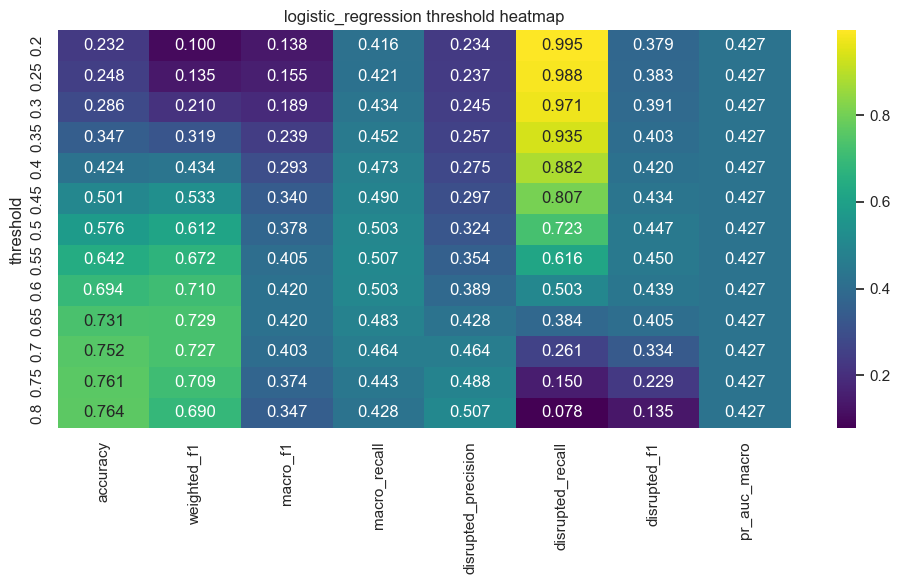

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\logistic_regression_threshold_heatmap.png


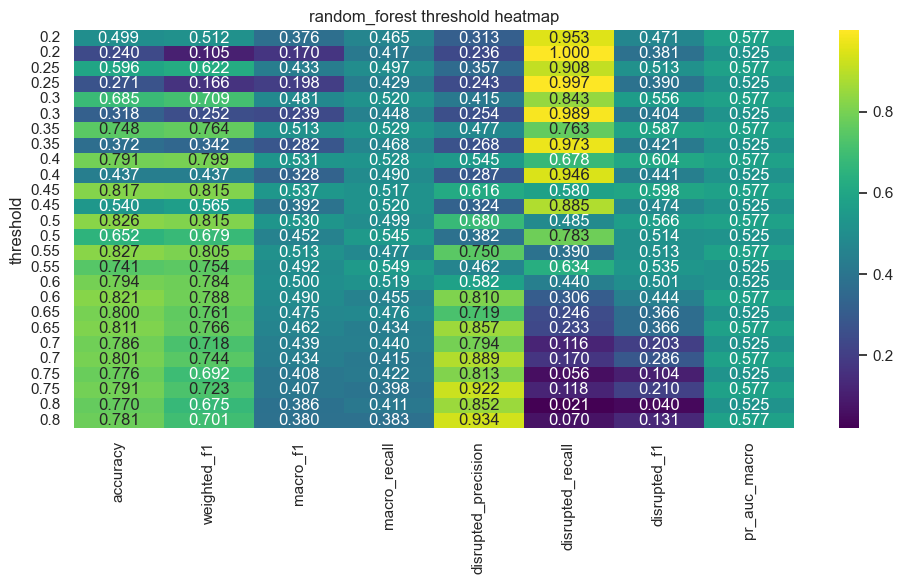

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\random_forest_threshold_heatmap.png


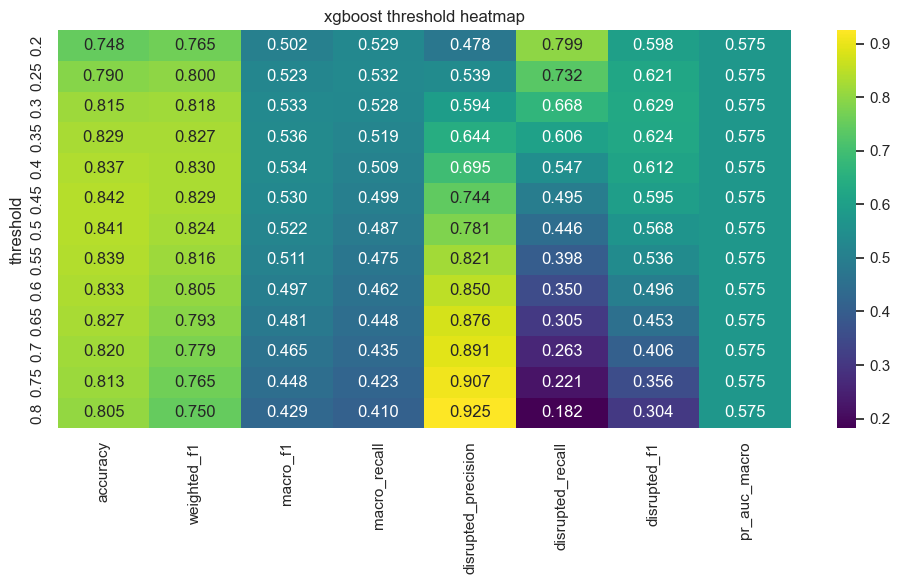

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\xgboost_threshold_heatmap.png


In [49]:
for model_name in sorted(plot_df['model'].unique()):
    subset = plot_df[plot_df['model'] == model_name].copy()
    heat = subset.set_index('threshold')[metric_cols]
    plt.figure(figsize=(10, 6))
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis', cbar=True)
    plt.title(f'{model_name} threshold heatmap')
    plt.tight_layout()
    out_path = OUTPUT_DIR / f'{model_name}_threshold_heatmap.png'
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


## Recommended Operating Points

This cell gives two useful views:

- **Balanced**: strongest macro-F1 with acceptable disrupted recall
- **Recall-first**: strongest disrupted recall without completely collapsing accuracy


In [50]:
balanced_choice = (
    results[results['accuracy'] >= 0.60]
    .sort_values(['macro_f1', 'disrupted_recall', 'accuracy'], ascending=False)
    .groupby('model')
    .head(3)
)

recall_first_choice = (
    results[results['accuracy'] >= 0.50]
    .sort_values(['disrupted_recall', 'macro_f1', 'accuracy'], ascending=False)
    .groupby('model')
    .head(3)
)

print('BALANCED CHOICES')
display_cols = [
    'model', 'threshold', 'accuracy', 'weighted_f1', 'macro_f1', 'macro_recall',
    'disrupted_precision', 'disrupted_recall', 'disrupted_f1', 'train_seconds',
    'param_C', 'param_class_weight', 'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf'
]
display(balanced_choice[[c for c in display_cols if c in balanced_choice.columns]].reset_index(drop=True))

print('RECALL-FIRST CHOICES')
display(recall_first_choice[[c for c in display_cols if c in recall_first_choice.columns]].reset_index(drop=True))


BALANCED CHOICES


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.45,0.816742,0.814602,0.537064,0.516824,0.616125,0.580345,0.597700,152.013022,NaN,balanced_subsample,400.0,NaN,5.0
1,random_forest,0.45,0.814595,0.812807,0.536695,0.516068,0.610047,0.581238,0.595294,81.175223,NaN,balanced_subsample,200.0,NaN,5.0
2,xgboost,0.35,0.828820,0.826719,0.535803,0.519006,0.643739,0.605616,0.624096,22.609545,NaN,NaN,200.0,8.0,NaN
3,xgboost,0.40,0.837379,0.829987,0.534463,0.509092,0.694940,0.546905,0.612099,22.609545,NaN,NaN,200.0,8.0,NaN
4,xgboost,0.30,0.814923,0.818332,0.532535,0.527521,0.593761,0.668028,0.628709,22.609545,NaN,NaN,200.0,8.0,NaN
5,random_forest,0.40,0.791453,0.798590,0.531470,0.528363,0.544680,0.677601,0.603913,152.013022,NaN,balanced_subsample,400.0,NaN,5.0
6,logistic_regression,0.60,0.693904,0.709622,0.419624,0.503409,0.388900,0.502616,0.438506,3.237850,1.00,balanced,NaN,NaN,NaN
7,logistic_regression,0.60,0.693904,0.709622,0.419624,0.503409,0.388900,0.502616,0.438506,3.187870,4.00,balanced,NaN,NaN,NaN
8,logistic_regression,0.60,0.693875,0.709612,0.419618,0.503426,0.388883,0.502744,0.438544,3.365492,0.25,balanced,NaN,NaN,NaN


RECALL-FIRST CHOICES


,model,threshold,accuracy,weighted_f1,macro_f1,macro_recall,disrupted_precision,disrupted_recall,disrupted_f1,train_seconds,param_C,param_class_weight,param_n_estimators,param_max_depth,param_min_samples_leaf
0,random_forest,0.20,0.500030,0.513528,0.363466,0.456860,0.313551,0.954180,0.471999,175.707398,NaN,balanced,400.0,NaN,5.0
1,random_forest,0.20,0.500149,0.513875,0.364236,0.456406,0.313309,0.951883,0.471443,80.013745,NaN,balanced,200.0,NaN,5.0
2,random_forest,0.25,0.597042,0.623019,0.420797,0.488577,0.358177,0.908998,0.513871,175.707398,NaN,balanced,400.0,NaN,5.0
3,logistic_regression,0.45,0.501223,0.532788,0.339659,0.489539,0.296628,0.807275,0.433843,3.187870,4.00,balanced,NaN,NaN,NaN
4,logistic_regression,0.45,0.501193,0.532755,0.339642,0.489526,0.296614,0.807275,0.433828,3.237850,1.00,balanced,NaN,NaN,NaN
5,logistic_regression,0.45,0.501044,0.532592,0.339553,0.489461,0.296545,0.807275,0.433754,3.365492,0.25,balanced,NaN,NaN,NaN
6,xgboost,0.20,0.756233,0.772410,0.493451,0.523932,0.487951,0.801149,0.606503,58.356116,NaN,NaN,400.0,10.0,NaN
7,xgboost,0.20,0.737922,0.756271,0.481919,0.515878,0.465786,0.801021,0.589047,66.168192,NaN,NaN,400.0,8.0,NaN
8,xgboost,0.20,0.750984,0.767766,0.490149,0.521351,0.481376,0.800000,0.601074,48.634061,NaN,NaN,323.0,10.0,NaN


## Notes

Interpretation guidance:

- If threshold is **lower**, the model predicts disruption more often.
  - disrupted recall usually goes **up**
  - accuracy may go **down**
  - false alarms may go **up**

- If threshold is **higher**, the model becomes more conservative.
  - accuracy often looks better
  - disrupted recall usually goes **down**
  - this is closer to a consumer-facing product that avoids too many false warnings

For airline/operations use, the most relevant metrics are usually:

- `disrupted_recall`
- `disrupted_precision`
- `macro_f1`
- `accuracy` as a secondary guardrail


## Snapshot Comparison

Compare the archived weighted runs side-by-side using the saved `models/model_comparison.json` artifacts.


In [11]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

OUTPUT_DIR = REPO_ROOT / "outputs" / "threshold_experiments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNAPSHOT_RUNS = {
    'weighted_1_1_1': REPO_ROOT / 'weighted_1_1_1_run',
    'weighted_1_2_5': REPO_ROOT / 'weighted_1_2_5_run',
    'weighted_1_2_10': REPO_ROOT / 'weighted_1_2_10_run',
}

def load_snapshot_metrics(run_name: str, run_dir: Path) -> list[dict]:
    comparison_path = run_dir / 'models' / 'model_comparison.json'
    if not comparison_path.exists():
        print(f'Skipping {run_name}: missing {comparison_path}')
        return []

    payload = json.loads(comparison_path.read_text(encoding="utf-8"))
    rows = []
    weights_label = run_name.replace('weighted_', '').replace('_', '/')

    for item in payload.get("ranking", []):
        disrupted_metrics = item.get("per_class_metrics", {}).get("Disrupted", {})
        rows.append({
            'run_name': run_name,
            'weights': weights_label,
            'model': item.get('model'),
            'best_model_for_run': payload.get('best_model'),
            'accuracy': item.get('accuracy'),
            'weighted_f1': item.get('weighted_f1'),
            'macro_f1': item.get('macro_f1'),
            'cohens_kappa': item.get('cohens_kappa'),
            'pr_auc_macro': item.get('pr_auc_macro'),
            'disrupted_recall': disrupted_metrics.get('recall'),
            'disrupted_precision': disrupted_metrics.get('precision'),
        })
    return rows

snapshot_rows = []
for run_name, run_dir in SNAPSHOT_RUNS.items():
    snapshot_rows.extend(load_snapshot_metrics(run_name, run_dir))

snapshot_results = pd.DataFrame(snapshot_rows)
snapshot_results


,run_name,weights,model,best_model_for_run,accuracy,weighted_f1,macro_f1,cohens_kappa,pr_auc_macro,disrupted_recall,disrupted_precision
0,weighted_1_1_1,1/1/1,xgboost,xgboost,0.805678,0.812536,0.749002,0.500138,None,0.707211,0.567551
1,weighted_1_1_1,1/1/1,random_forest,xgboost,0.818860,0.781761,0.655250,0.341099,None,0.278111,0.839045
2,weighted_1_1_1,1/1/1,logistic_regression,xgboost,0.653018,0.677869,0.601770,0.230273,None,0.629738,0.360989
3,weighted_1_2_5,1/2/5,xgboost,xgboost,0.789813,0.799453,0.735867,0.476028,None,0.723038,0.537323
4,weighted_1_2_5,1/2/5,random_forest,xgboost,0.818860,0.781761,0.655250,0.341099,None,0.278111,0.839045
5,weighted_1_2_5,1/2/5,logistic_regression,xgboost,0.653018,0.677869,0.601770,0.230273,None,0.629738,0.360989
6,weighted_1_2_10,1/2/10,xgboost,xgboost,0.769295,0.782447,0.719467,0.447251,None,0.744352,0.504280
7,weighted_1_2_10,1/2/10,random_forest,xgboost,0.815937,0.776077,0.644666,0.323431,None,0.260370,0.844022
8,weighted_1_2_10,1/2/10,logistic_regression,xgboost,0.388793,0.375309,0.387883,0.077308,None,0.914486,0.265469


In [12]:
from IPython.display import display
import pandas as pd

comparison_table = snapshot_results[['weights', 'model', 'accuracy', 'disrupted_recall', 'disrupted_precision', 'weighted_f1', 'macro_f1', 'cohens_kappa', 'pr_auc_macro']].copy()
comparison_table = comparison_table.sort_values(['model', 'weights']).reset_index(drop=True)

def fmt4(x):
    return 'N/A' if pd.isna(x) else f'{x:.4f}'

display(
    comparison_table.style.format({
        'accuracy': fmt4,
        'disrupted_recall': fmt4,
        'disrupted_precision': fmt4,
        'weighted_f1': fmt4,
        'macro_f1': fmt4,
        'cohens_kappa': fmt4,
        'pr_auc_macro': fmt4,
    })
)

comparison_csv_path = OUTPUT_DIR / 'weighted_run_comparison.csv'
comparison_table.to_csv(comparison_csv_path, index=False)
print('Saved:', comparison_csv_path)


,weights,model,accuracy,disrupted_recall,disrupted_precision,weighted_f1,macro_f1,cohens_kappa,pr_auc_macro
0,1/1/1,logistic_regression,0.6530,0.6297,0.3610,0.6779,0.6018,0.2303,N/A
1,1/2/10,logistic_regression,0.3888,0.9145,0.2655,0.3753,0.3879,0.0773,N/A
2,1/2/5,logistic_regression,0.6530,0.6297,0.3610,0.6779,0.6018,0.2303,N/A
3,1/1/1,random_forest,0.8189,0.2781,0.8390,0.7818,0.6552,0.3411,N/A
4,1/2/10,random_forest,0.8159,0.2604,0.8440,0.7761,0.6447,0.3234,N/A
5,1/2/5,random_forest,0.8189,0.2781,0.8390,0.7818,0.6552,0.3411,N/A
6,1/1/1,xgboost,0.8057,0.7072,0.5676,0.8125,0.7490,0.5001,N/A
7,1/2/10,xgboost,0.7693,0.7444,0.5043,0.7824,0.7195,0.4473,N/A
8,1/2/5,xgboost,0.7898,0.7230,0.5373,0.7995,0.7359,0.4760,N/A


Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\weighted_run_comparison.csv


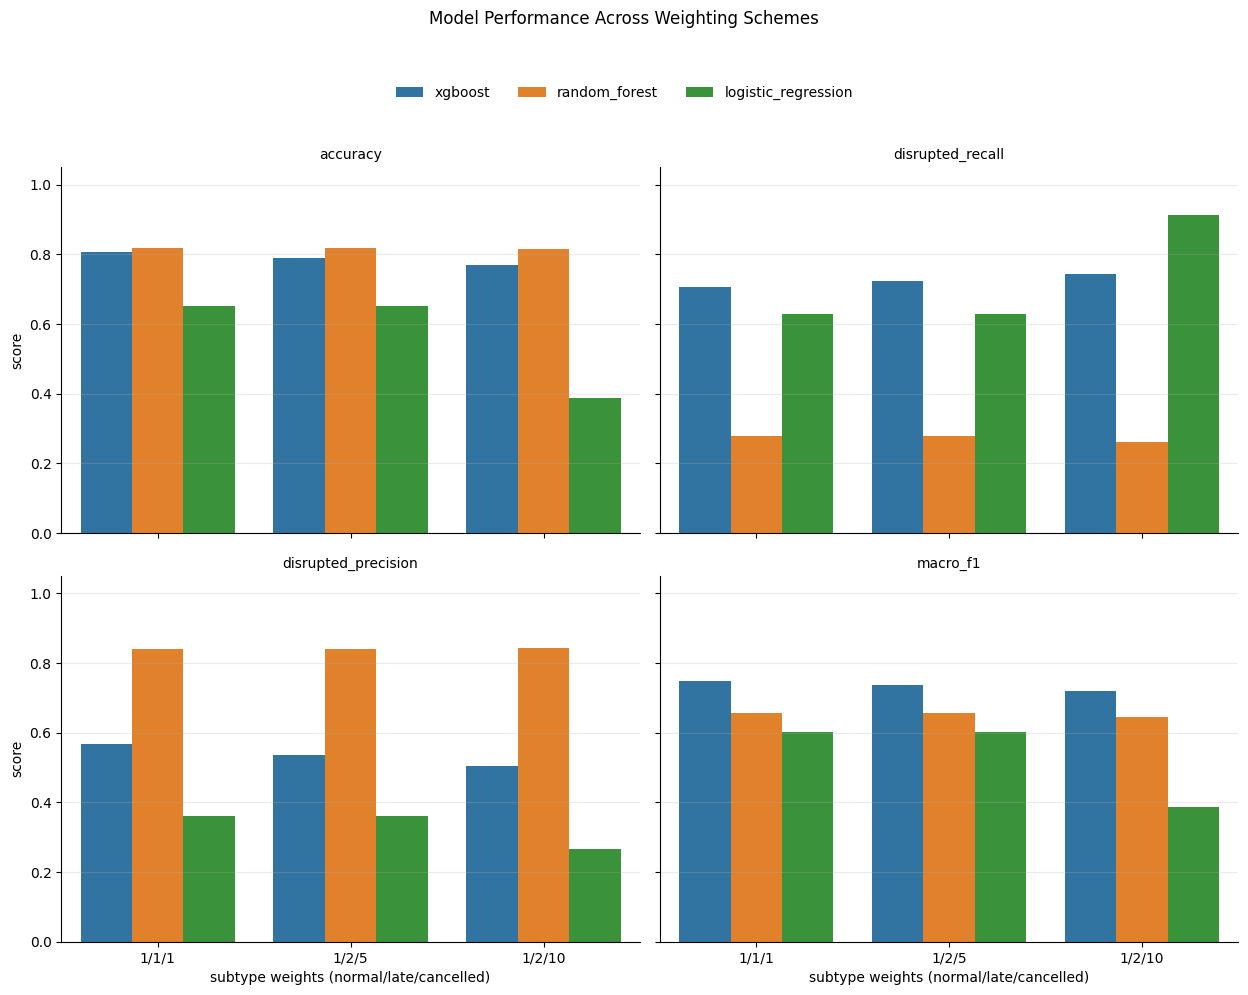

Saved: C:\Code\flight-disruption-prediction\outputs\threshold_experiments\weighted_run_accuracy_recall_precision_macrof1.png
Accuracy by weight setting:


weights,1/1/1,1/2/10,1/2/5
model,,,
logistic_regression,0.6530,0.3888,0.6530
random_forest,0.8189,0.8159,0.8189
xgboost,0.8057,0.7693,0.7898


Disrupted recall by weight setting:


weights,1/1/1,1/2/10,1/2/5
model,,,
logistic_regression,0.6297,0.9145,0.6297
random_forest,0.2781,0.2604,0.2781
xgboost,0.7072,0.7444,0.7230


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plot_metrics = ['accuracy', 'disrupted_recall', 'disrupted_precision', 'macro_f1']
plot_df = snapshot_results.melt(
    id_vars=['weights', 'model'],
    value_vars=plot_metrics,
    var_name='metric',
    value_name='score',
)

g = sns.catplot(
    data=plot_df,
    x="weights",
    y="score",
    hue="model",
    col="metric",
    kind="bar",
    col_wrap=2,
    height=4.5,
    aspect=1.2,
    sharey=True,
)

g.set_titles("{col_name}")
g.set_axis_labels("subtype weights (normal/late/cancelled)", "score")

for ax in g.axes.flatten():
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.25)

if g._legend is not None:
    handles = g._legend.legend_handles
    labels = [t.get_text() for t in g._legend.texts]
    g._legend.remove()
    g.fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=max(1, len(labels)),
        bbox_to_anchor=(0.5, 1.03),
        frameon=False,
    )

g.fig.suptitle("Model Performance Across Weighting Schemes", y=1.10)
g.fig.tight_layout()

weights_plot_path = OUTPUT_DIR / 'weighted_run_accuracy_recall_precision_macrof1.png'
g.fig.savefig(weights_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print('Saved:', weights_plot_path)

pivot_accuracy = snapshot_results.pivot(index="model", columns="weights", values="accuracy")
pivot_recall = snapshot_results.pivot(index="model", columns="weights", values="disrupted_recall")

print('Accuracy by weight setting:')
display(pivot_accuracy.style.format("{:.4f}"))
print('Disrupted recall by weight setting:')
display(pivot_recall.style.format("{:.4f}"))
